# Hit-Prediction aus Audio-Features

**Fragestellung:** Lässt sich allein anhand musikalischer Eigenschaften vorhersagen, ob ein Song ein Hit wird (`popularity > 70`), bevor Nutzersignale vorliegen?

**Mehrwert für Spotify:** Songs mit starker Hit-DNA können frühzeitig priorisiert werden (z. B. in Editorial- oder Discovery-Playlists), statt erst auf erste Nutzungsdaten zu warten.

## Analysevertrag
- **Feature-Raum (X):** nur `audio_features`
- **Targets (y):**
  - Klassifikation: `is_hit = popularity > 70`
  - Regression: `popularity` als kontinuierlicher Wert
- **Modelle:** Dummy-Baselines, klassische ML-Modelle, Feed Forward Neural Network (TensorFlow/Keras)
- **Wichtiger Guardrail:** kein Nutzerverhalten, keine Genre-Metadaten als Features

In [1]:
import warnings
import sqlite3 as sl
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

RANDOM_STATE = 42
HIT_THRESHOLD = 70
# Nimmt nur jede n-te DB-Zeile, um Laufzeit und RAM deutlich zu reduzieren.
SAMPLE_MODULO = 5
# Trainingsparameter fuer ein vollwertigeres FNN-Training.
NN_EPOCHS = 120
NN_BATCH_SIZE = 512
TF_IMPORT_ERROR = None

try:
    import tensorflow as tf
    TF_AVAILABLE = True
    # Setzt reproduzierbare Zufallswerte fuer TensorFlow-Initialisierung.
    tf.random.set_seed(RANDOM_STATE)
except Exception as exc:
    TF_AVAILABLE = False
    # Speichert den Importfehler fuer eine spaetere, klare Ausgabe.
    TF_IMPORT_ERROR = repr(exc)

In [2]:
con = sl.connect('spotify.sqlite')
# Robust gegen kaputte Zeichen in Textfeldern der SQLite-Datei.
con.text_factory = lambda b: b.decode(errors='ignore')

def run_sql(query: str) -> pd.DataFrame:
    # Fuehrt SQL aus und liefert direkt ein DataFrame fuer Pandas-Analysen.
    return pd.read_sql_query(query, con)

feature_cols = [
    'acousticness',
    'danceability',
    'energy',
    'instrumentalness',
    'liveness',
    'speechiness',
    'valence',
    'loudness',
    'tempo',
    'key',
    'mode',
    'time_signature',
    'duration',
]

## 1) Datensatz aufbauen und qualitaetssichern
Wir verbinden `tracks` mit `audio_features`, filtern offensichtliche Ausreißer/ungültige Werte und entfernen Duplikate auf `audio_feature_id`.

In [3]:
#TODO: Es wurde hier gar nicht bereinigt sondern nur gefiltert. Zuerst müssen wir uns alle Daten holen und dann bereinigen, damit wir die Qualitätssicherung durchführen können (z.B. Anzahl der Zeilen vor/nach Bereinigung, Anzahl der Duplikate, Verteilung der Zielvariable vor/nach Bereinigung etc.). Das ist wichtig, um sicherzustellen, dass wir nicht versehentlich zu viele Daten durch zu strenge Filter entfernen und um die Auswirkungen der Bereinigung auf die Datenqualität zu verstehen.
df_raw = run_sql(f"""
SELECT
    af.id AS audio_feature_id,
    t.id AS track_id,
    t.name AS track_name,
    t.popularity,
    af.acousticness,
    af.danceability,
    af.energy,
    af.instrumentalness,
    af.liveness,
    af.speechiness,
    af.valence,
    af.loudness,
    af.tempo,
    af.key,
    af.mode,
    af.time_signature,
    af.duration
FROM tracks t
JOIN audio_features af ON t.audio_feature_id = af.id
WHERE t.popularity BETWEEN 0 AND 100 -- TODO: Von-Bis überprüfen
  AND af.rowid % {SAMPLE_MODULO} = 0
  AND af.acousticness BETWEEN 0 AND 1
  AND af.danceability BETWEEN 0 AND 1
  AND af.energy BETWEEN 0 AND 1
  AND af.instrumentalness BETWEEN 0 AND 1
  AND af.liveness BETWEEN 0 AND 1
  AND af.speechiness BETWEEN 0 AND 1
  AND af.valence BETWEEN 0 AND 1
  AND af.tempo > 0
  AND af.duration > 0
  AND af.key BETWEEN 0 AND 11 -- TODO: Manche Tracks haben laut Spotify-API key=-1, was "unknown" bedeutet. Wie damit umgehen? Aktuell werden sie rausgefiltert, aber vielleicht sollten wir sie lieber in einer eigenen Kategorie behalten
  AND af.mode IN (0, 1)
  AND af.time_signature BETWEEN 1 AND 7
  -- TODO: Loudness vergessen, der Wertebereich ist laut Spotify-API typischerweise etwa -60 bis 0 dB
""")

print('--- SQL-Extraktion abgeschlossen ---')
print(f'Rohdatensatz: {df_raw.shape[0]:,} Zeilen x {df_raw.shape[1]} Spalten')
print('Spalten:', ', '.join(df_raw.columns.tolist()))
print('Beispielzeilen (erste 3):')
display(df_raw.head(3))

# Merkt sich die Rohmenge vor Cleaning fuer den Qualitaetsbericht.
rows_before = len(df_raw)
# Zaehlt doppelte Audio-Feature-IDs, um Mehrfachzuordnungen sichtbar zu machen.
duplicates = int(df_raw.duplicated(subset='audio_feature_id').sum())

# Entfernt Duplikate/Nullwerte und erstellt eine saubere Modellbasis.
df_model = (
    df_raw
    .drop_duplicates(subset='audio_feature_id')
    .dropna(subset=feature_cols + ['popularity'])
    .reset_index(drop=True)
    .copy()
)

# Binaeres Ziel: 1 = Hit, wenn Popularity strikt ueber Schwellwert liegt. TODO: Es muss noch am Anfang der Analyse geschrieben werden/herausgefunden werden, wie wir überhaupt zu den 70 Punkten kommen, damit wir die Hit-Schwelle definieren können. Vielleicht ist es sinnvoll, die Hit-Schwelle so zu setzen, dass wir eine gewisse Anzahl von Hits im Datensatz haben, z.B. 1% der Songs als Hits klassifizieren. Wir müssen alles begründen, aktuell ist sie wirklich willkürlich gewählt.
df_model['is_hit'] = (df_model['popularity'] > HIT_THRESHOLD).astype(int)

print('\n--- Nach Cleaning / Feature-Engineering ---')
print(f'Modelldatensatz: {len(df_model):,} Zeilen')
print(f'Hit-Schwelle: popularity > {HIT_THRESHOLD}')
print('Klassenhaeufigkeit is_hit (absolut):')
print(df_model['is_hit'].value_counts().sort_index())
print('Klassenanteile is_hit (relativ):')
print((df_model['is_hit'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + ' %')

overview = pd.DataFrame([
    {'Artefakt': 'Rows vor Dedup', 'Anzahl': rows_before},
    {'Artefakt': 'Duplikate audio_feature_id', 'Anzahl': duplicates},
    {'Artefakt': 'Rows nach Dedup/Cleaning', 'Anzahl': len(df_model)},
    {'Artefakt': 'Sampling-Modulo', 'Anzahl': SAMPLE_MODULO},
    {'Artefakt': 'Hit-Anteil [%]', 'Anzahl': df_model['is_hit'].mean() * 100},
])
display(overview)

# Bricht frueh ab, falls durch Filter unabsichtlich keine Daten mehr da sind.
assert not df_model.empty, 'Modelldatensatz ist leer. SQL-Filter pruefen.'
# Verhindert untrainierbares Klassifikationsproblem mit nur einer Klasse.
assert df_model['is_hit'].nunique() == 2, 'Target is_hit hat nur eine Klasse. Schwelle/Filter pruefen.'

--- SQL-Extraktion abgeschlossen ---
Rohdatensatz: 1,741,187 Zeilen x 17 Spalten
Spalten: audio_feature_id, track_id, track_name, popularity, acousticness, danceability, energy, instrumentalness, liveness, speechiness, valence, loudness, tempo, key, mode, time_signature, duration
Beispielzeilen (erste 3):


,audio_feature_id,track_id,track_name,popularity,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,loudness,tempo,key,mode,time_signature,duration
0,3UOuBNEin5peSRqdzvlnWM,3UOuBNEin5peSRqdzvlnWM,Still D.R.E.,66,0.1700,0.8140,0.7810,0.0005,0.0520,0.2330,0.5360,-3.3300,93.4450,11,1,4,270667
1,7N1Vjtzr1lmmCW9iasQ8YO,7N1Vjtzr1lmmCW9iasQ8YO,Survival of the Fittest,70,0.1250,0.8130,0.7030,0.0000,0.2370,0.2680,0.2410,-5.0770,94.8280,11,0,4,224533
2,3gY6tiCNsuVi6s8kPV6aQg,3gY6tiCNsuVi6s8kPV6aQg,Nas Is Like,66,0.0060,0.6340,0.8450,0.0000,0.0598,0.3520,0.9290,-5.0580,94.0000,11,0,4,237027



--- Nach Cleaning / Feature-Engineering ---
Modelldatensatz: 1,741,128 Zeilen
Hit-Schwelle: popularity > 70
Klassenhaeufigkeit is_hit (absolut):
is_hit
0    1739949
1       1179
Name: count, dtype: int64
Klassenanteile is_hit (relativ):
is_hit
0    99.93 %
1     0.07 %
Name: proportion, dtype: object


,Artefakt,Anzahl
0,Rows vor Dedup,"1,741,187.0000"
1,Duplikate audio_feature_id,59.0000
2,Rows nach Dedup/Cleaning,"1,741,128.0000"
3,Sampling-Modulo,5.0000
4,Hit-Anteil [%],0.0677


## 2) Deskriptive Statistik und Visualisierungen

,count,mean,std,min,25%,50%,75%,max
acousticness,"1,741,128.0000",0.4187,0.3756,0.0000,0.0330,0.3300,0.8110,0.9960
danceability,"1,741,128.0000",0.5353,0.1891,0.0000,0.4020,0.5500,0.6800,1.0000
energy,"1,741,128.0000",0.5485,0.2812,0.0000,0.3190,0.5720,0.7920,1.0000
instrumentalness,"1,741,128.0000",0.2554,0.3680,0.0000,0.0000,0.0018,0.6310,1.0000
liveness,"1,741,128.0000",0.2065,0.1813,0.0000,0.0964,0.1300,0.2640,1.0000
speechiness,"1,741,128.0000",0.0966,0.1408,0.0000,0.0360,0.0475,0.0836,0.9720
valence,"1,741,128.0000",0.4824,0.2791,0.0000,0.2420,0.4770,0.7160,1.0000
loudness,"1,741,128.0000",-10.7601,6.2295,-60.0000,-13.4830,-9.1210,-6.3590,5.2460
tempo,"1,741,128.0000",119.1174,30.1590,30.0940,95.5830,119.3190,137.6680,249.9700
key,"1,741,128.0000",5.2477,3.5418,0.0000,2.0000,5.0000,8.0000,11.0000


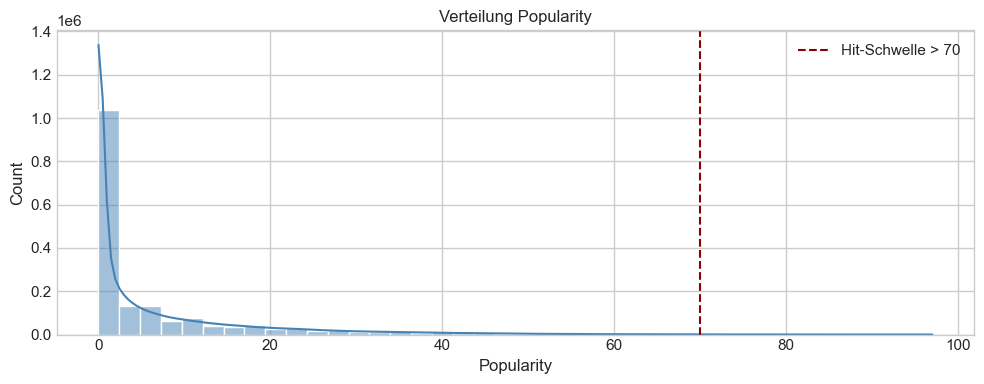

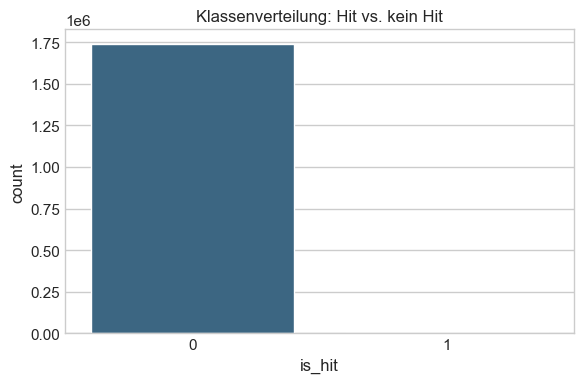

In [4]:
# Numerische Lage-/Streuungsmasse pro Feature + Zielvariable.
display(df_model[feature_cols + ['popularity']].describe().T)

plt.figure(figsize=(10, 4)) #TODO: Alle Grafiken müssen in höherer Auflösung sein, momentan sind sie teilweise unscharf
sns.histplot(df_model['popularity'], bins=40, kde=True, color='steelblue')
plt.axvline(HIT_THRESHOLD, color='darkred', linestyle='--', label=f'Hit-Schwelle > {HIT_THRESHOLD}')
plt.title('Verteilung Popularity')
plt.xlabel('Popularity')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x='is_hit', palette='viridis')
plt.title('Klassenverteilung: Hit vs. kein Hit')
plt.xlabel('is_hit')
plt.tight_layout()
plt.show()

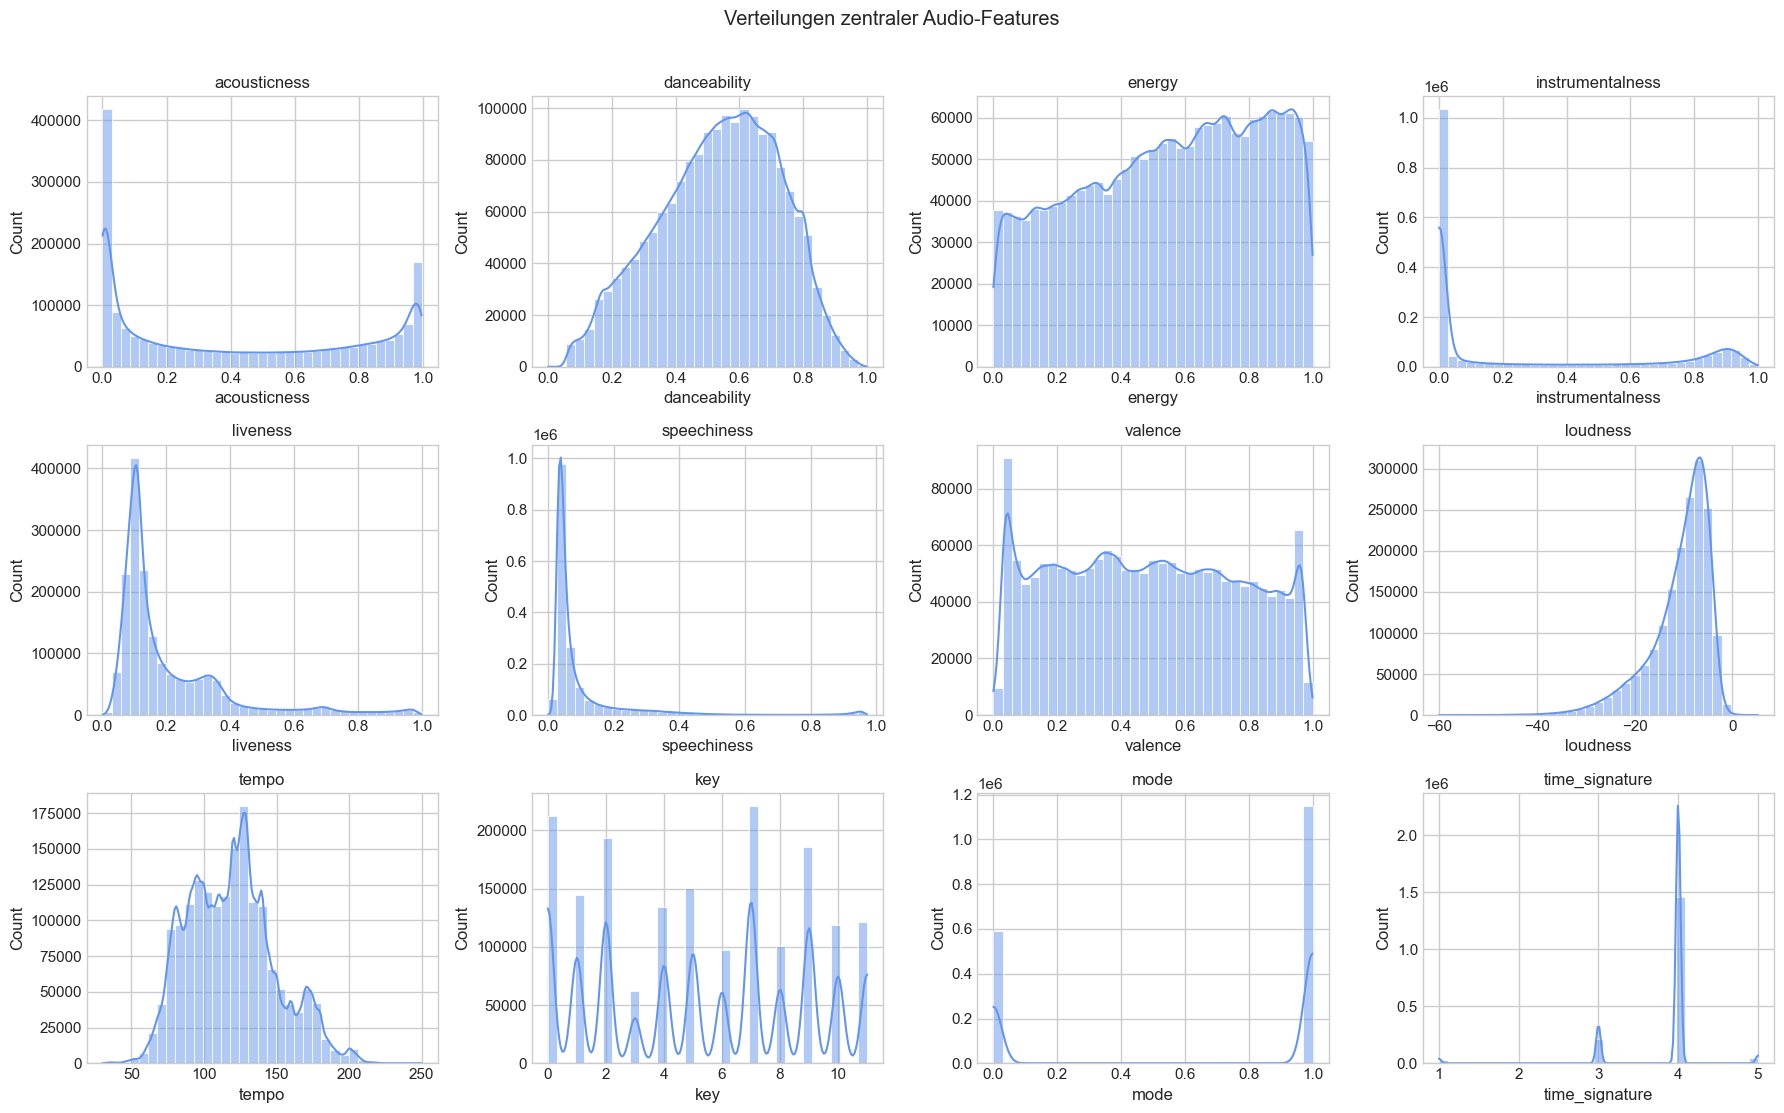

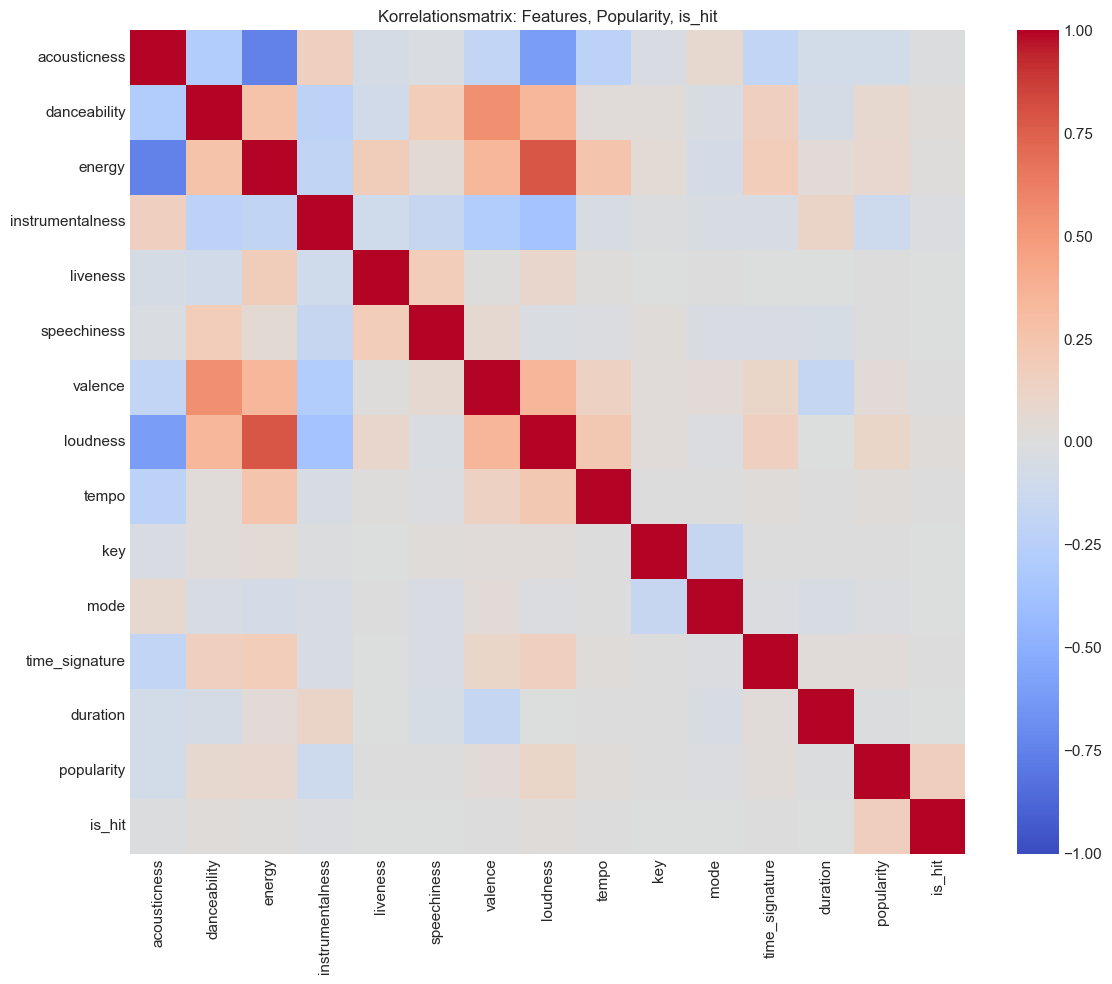

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
# Macht aus 2D-Array eine lineare Liste, damit for-loop einfacher ist.
axes = axes.flatten()

for ax, col in zip(axes, feature_cols[:12]):
    sns.histplot(df_model[col], bins=35, kde=True, ax=ax, color='cornflowerblue')
    ax.set_title(col)

plt.suptitle('Verteilungen zentraler Audio-Features', y=1.01)
plt.tight_layout()
plt.show()

corr_cols = feature_cols + ['popularity', 'is_hit']
# Pearson-Korrelation zur schnellen Muster- und Redundanzpruefung.
corr = df_model[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Korrelationsmatrix: Features, Popularity, is_hit')
plt.tight_layout()
plt.show()

## 3) Daten-Split (Leakage-sicher)
Wir splitten zuerst, dann lernen Skalierungs-Parameter nur auf dem Trainingsset.

In [6]:
X = df_model[feature_cols].copy()
y_cls = df_model['is_hit'].copy()
y_reg = df_model['popularity'].copy()

# 70/30 Split; Stratify haelt Hit-Anteil stabil in Train/Temp.
X_train, X_temp, y_train_cls, y_temp_cls, y_train_reg, y_temp_reg = train_test_split(
    X,
    y_cls,
    y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_cls,
)

# Temp wird 50/50 geteilt -> final 15% Validation, 15% Test.
X_val, X_test, y_val_cls, y_test_cls, y_val_reg, y_test_reg = train_test_split(
    X_temp,
    y_temp_cls,
    y_temp_reg,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp_cls,
)

split_info = pd.DataFrame([
    {'Split': 'Train', 'Rows': len(X_train), 'Hit-Quote': y_train_cls.mean()},
    {'Split': 'Validation', 'Rows': len(X_val), 'Hit-Quote': y_val_cls.mean()},
    {'Split': 'Test', 'Rows': len(X_test), 'Hit-Quote': y_test_cls.mean()},
])
display(split_info)

print('\n--- Split-Details ---')
print(f'Gesamt: {len(X):,} | Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print('Train-Klassen:', y_train_cls.value_counts().sort_index().to_dict())
print('Val-Klassen  :', y_val_cls.value_counts().sort_index().to_dict())
print('Test-Klassen :', y_test_cls.value_counts().sort_index().to_dict())

,Split,Rows,Hit-Quote
0,Train,1218789,0.0007
1,Validation,261169,0.0007
2,Test,261170,0.0007



--- Split-Details ---
Gesamt: 1,741,128 | Train: 1,218,789 | Val: 261,169 | Test: 261,170
Train-Klassen: {0: 1217964, 1: 825}
Val-Klassen  : {0: 260992, 1: 177}
Test-Klassen : {0: 260993, 1: 177}


## 4) Klassifikation: Baselines und klassische ML-Modelle

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
cls_models = {
    'DummyMostFrequent': Pipeline([
        ('model', DummyClassifier(strategy='most_frequent'))
    ]),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),
    'RandomForestClassifier': Pipeline([
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    'HistGradientBoostingClassifier': Pipeline([
        ('model', HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ]),
}

def evaluate_classifier(model, X_eval: pd.DataFrame, y_true: pd.Series) -> dict:
    # Hartes Klassenlabel (0/1) fuer Accuracy/Precision/Recall/F1.
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        # Nutzt Wahrscheinlichkeiten fuer ROC-AUC (sauberer als harte Labels).
        y_proba = model.predict_proba(X_eval)[:, 1]
    else:
        # Fallback, falls ein Modell keine predict_proba-Schnittstelle hat.
        y_proba = y_pred.astype(float)

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
    }

cls_rows = []
fitted_cls_models = {}

for name, model in cls_models.items():
    # Trainiert jedes Modell auf dem identischen Trainingssplit.
    print(f"\n[CLS] Starte Training: {name}")
    print(f"[CLS] Train-Daten: X={X_train.shape}, y={y_train_cls.shape}")
    model.fit(X_train, y_train_cls)
    fitted_cls_models[name] = model
    # Bewertet auf Validation (nicht auf Test), um Modellwahl fair zu halten.
    metrics_val = evaluate_classifier(model, X_val, y_val_cls)
    print('[CLS] Validation-Metriken:', {k: round(v, 4) for k, v in metrics_val.items()})
    cls_rows.append({'model': name, **metrics_val})

# Sortiert nach ROC-AUC, dann F1 als zweite Prioritaet.
df_cls_val = pd.DataFrame(cls_rows).sort_values(['roc_auc', 'f1'], ascending=False).reset_index(drop=True)
display(df_cls_val.round(4))

# Nimmt das Validation-beste Modell fuer den finalen Testcheck.
best_cls_name = df_cls_val.iloc[0]['model']
best_cls_model = fitted_cls_models[best_cls_name]
print(f'Bestes Klassifikationsmodell (Validation): {best_cls_name}')


[CLS] Starte Training: DummyMostFrequent
[CLS] Train-Daten: X=(1218789, 13), y=(1218789,)
[CLS] Validation-Metriken: {'accuracy': 0.9993, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': np.float64(0.5)}

[CLS] Starte Training: LogisticRegression
[CLS] Train-Daten: X=(1218789, 13), y=(1218789,)
[CLS] Validation-Metriken: {'accuracy': 0.6843, 'precision': 0.0017, 'recall': 0.8023, 'f1': 0.0034, 'roc_auc': np.float64(0.8235)}

[CLS] Starte Training: RandomForestClassifier
[CLS] Train-Daten: X=(1218789, 13), y=(1218789,)
[CLS] Validation-Metriken: {'accuracy': 0.9431, 'precision': 0.0045, 'recall': 0.3785, 'f1': 0.0089, 'roc_auc': np.float64(0.8325)}

[CLS] Starte Training: HistGradientBoostingClassifier
[CLS] Train-Daten: X=(1218789, 13), y=(1218789,)
[CLS] Validation-Metriken: {'accuracy': 0.8429, 'precision': 0.0027, 'recall': 0.6215, 'f1': 0.0053, 'roc_auc': np.float64(0.8343)}


,model,accuracy,precision,recall,f1,roc_auc
0,HistGradientBoostingClassifier,0.8429,0.0027,0.6215,0.0053,0.8343
1,RandomForestClassifier,0.9431,0.0045,0.3785,0.0089,0.8325
2,LogisticRegression,0.6843,0.0017,0.8023,0.0034,0.8235
3,DummyMostFrequent,0.9993,0.0000,0.0000,0.0000,0.5000


Bestes Klassifikationsmodell (Validation): HistGradientBoostingClassifier


Testmetriken bestes Klassifikationsmodell:
accuracy    0.8451
precision   0.0027
recall      0.6215
f1          0.0054
roc_auc     0.8461
dtype: float64
Testdaten fuer Klassifikation: X=(261170, 13), y=(261170,)
Vorhersageverteilung auf Test (0/1): {0: 220674, 1: 40496}


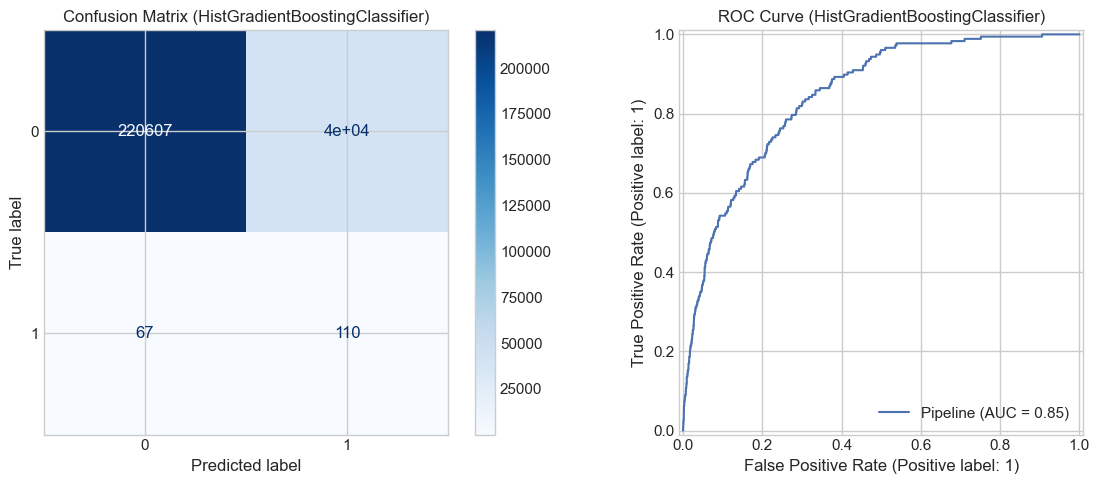

In [8]:
metrics_test = evaluate_classifier(best_cls_model, X_test, y_test_cls)
print('Testmetriken bestes Klassifikationsmodell:')
print(pd.Series(metrics_test).round(4))
print(f'Testdaten fuer Klassifikation: X={X_test.shape}, y={y_test_cls.shape}')

y_test_pred = best_cls_model.predict(X_test)
print('Vorhersageverteilung auf Test (0/1):', pd.Series(y_test_pred).value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_test_pred, ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix ({best_cls_name})')

if hasattr(best_cls_model, 'predict_proba'):
    RocCurveDisplay.from_estimator(best_cls_model, X_test, y_test_cls, ax=axes[1])
    axes[1].set_title(f'ROC Curve ({best_cls_name})')
else:
    # Bei Modellen ohne Wahrscheinlichkeiten keine ROC-Kurve zeichnen.
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5) Regression: Popularity als kontinuierliches Ziel

Berechne Feature Importances (das kann einen Moment dauern)...


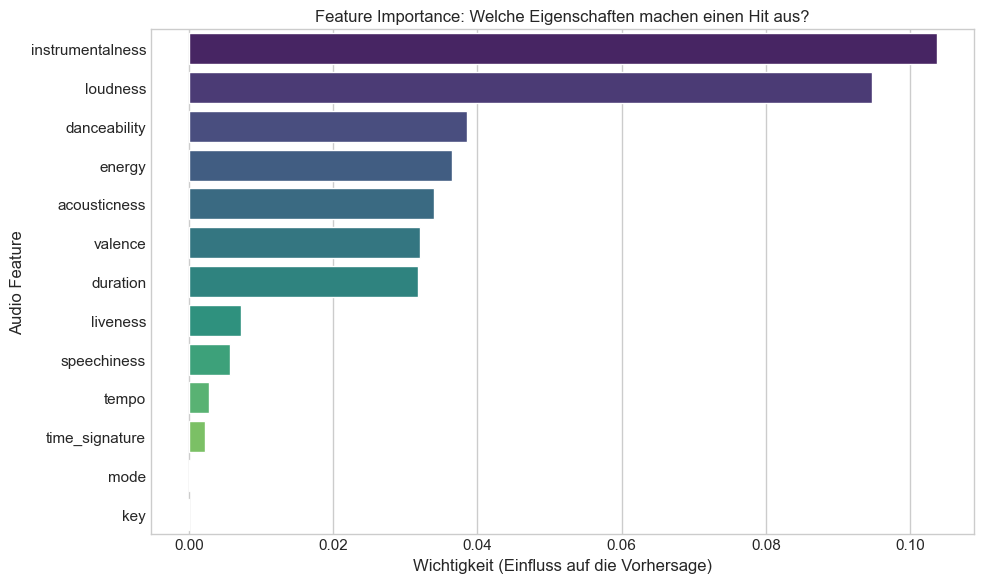

In [13]:
# Welche Eigenschaften machen einen Hit aus? Permutation Importance zeigt, welche Features den größten Einfluss auf die Vorhersage haben, indem es die Performance misst, wenn ein Feature zufällig permutiert wird. Je größer der Performance-Verlust, desto wichtiger ist das Feature für das Modell.
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

print("Berechne Feature Importances (das kann einen Moment dauern)...")

# Wir nehmen den HistGradientBoostingClassifier aus Ihrem Dictionary
best_model = fitted_cls_models['HistGradientBoostingClassifier']

# Permutation Importance berechnen (funktioniert für alle Modelle)
# Permutation Importance berechnen (jetzt mit der richtigen Metrik!)
result = permutation_importance(
    best_model,
    X_val,
    y_val_cls,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='roc_auc',         # <--- DAS IST DIE MAGISCHE NEUE ZEILE
    n_jobs=-1
)

# Der Rest Ihres Codes für das DataFrame und den Plot bleibt exakt gleich!

# Ergebnisse in ein DataFrame packen und sortieren
feature_names = X_val.columns
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Visualisierung
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance: Welche Eigenschaften machen einen Hit aus?')
plt.xlabel('Wichtigkeit (Einfluss auf die Vorhersage)')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()

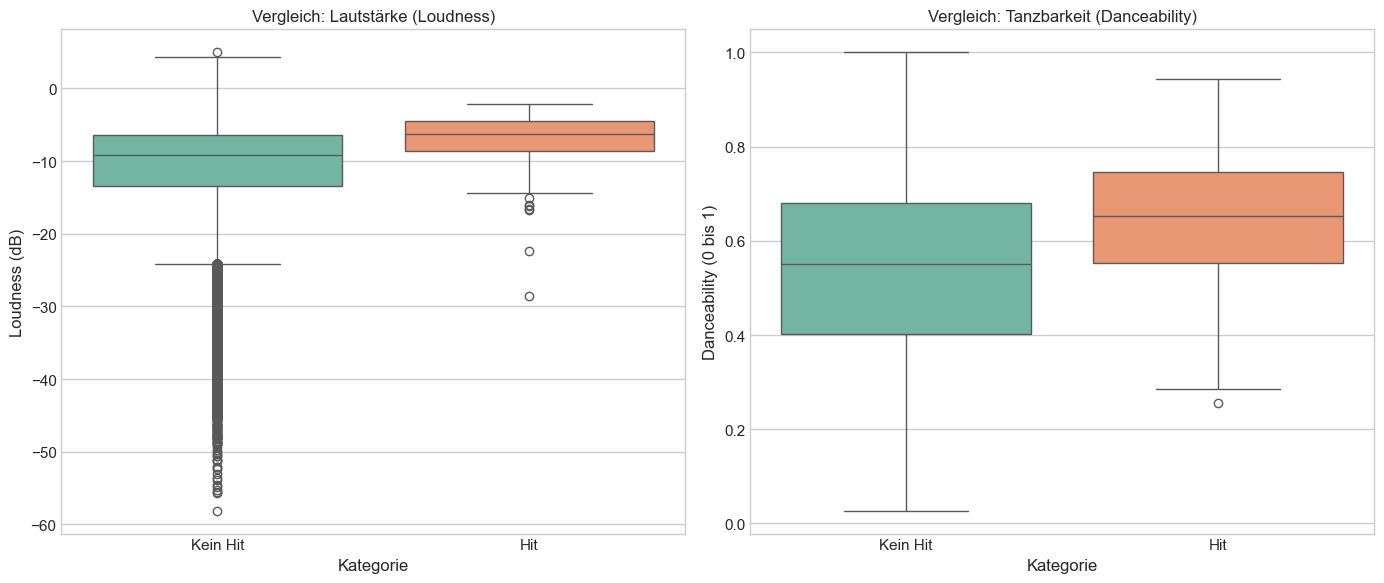

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wir erstellen ein DataFrame für die Visualisierung
# y_val_cls enthält Ihre 0 (Kein Hit) und 1 (Hit) Labels
df_vis = X_val.copy()
df_vis['Is_Hit'] = y_val_cls.values

# Wir wandeln die 0 und 1 in lesbare Texte um
df_vis['Kategorie'] = df_vis['Is_Hit'].map({0: 'Kein Hit', 1: 'Hit'})

# Figure mit 2 Subplots (nebeneinander) erstellen
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Loudness
sns.boxplot(data=df_vis, x='Kategorie', y='loudness', ax=axes[0], palette='Set2')
axes[0].set_title('Vergleich: Lautstärke (Loudness)')
axes[0].set_ylabel('Loudness (dB)')

# Plot 2: Danceability
sns.boxplot(data=df_vis, x='Kategorie', y='danceability', ax=axes[1], palette='Set2')
axes[1].set_title('Vergleich: Tanzbarkeit (Danceability)')
axes[1].set_ylabel('Danceability (0 bis 1)')

plt.tight_layout()
plt.show()

## 6) Feed Forward Neural Network (TensorFlow/Keras)


--- TensorFlow / Keras: Setup ---
Train: 1,218,789 | Val: 261,169 | Test: 261,170
Features pro Sample: 13
Konfiguration: epochs=120, batch_size=512, random_state=42
Class counts (Train): {0: 1217964, 1: 825}
Class weights: {0: np.float64(0.5003), 1: np.float64(738.66)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,593 (182.00 KB)

 Trainable params: 45,697 (178.50 KB)

 Non-trainable params: 896 (3.50 KB)

[Epoch 001] loss=0.5794 val_loss=0.5402 acc=0.6265 val_acc=0.6824 auc=0.7907 val_auc=0.8268
[Epoch 002] loss=0.5357 val_loss=0.5070 acc=0.6721 val_acc=0.7322 auc=0.8262 val_auc=0.8307
[Epoch 003] loss=0.5248 val_loss=0.4841 acc=0.6973 val_acc=0.7395 auc=0.8363 val_auc=0.8339
[Epoch 004] loss=0.5231 val_loss=0.4944 acc=0.7016 val_acc=0.7283 auc=0.8389 val_auc=0.8371
[Epoch 005] loss=0.5177 val_loss=0.4613 acc=0.6940 val_acc=0.7509 auc=0.8421 val_auc=0.8414
[Epoch 006] loss=0.5121 val_loss=0.4821 acc=0.6994 val_acc=0.7240 auc=0.8469 val_auc=0.8403
[Epoch 007] loss=0.5083 val_loss=0.4750 acc=0.7001 val_acc=0.7378 auc=0.8490 val_auc=0.8405
[Epoch 008] loss=0.5046 val_loss=0.4709 acc=0.7046 val_acc=0.7361 auc=0.8494 val_auc=0.8391
[Epoch 009] loss=0.5041 val_loss=0.4652 acc=0.7117 val_acc=0.7569 auc=0.8506 val_auc=0.8426
[Epoch 010] loss=0.4955 val_loss=0.4769 acc=0.7159 val_acc=0.7334 auc=0.8556 val_auc=0.8400
[Epoch 011] loss=0.4950 val_loss=0.4790 acc=0.7119 val_acc=0.7347 auc=0.8565 val

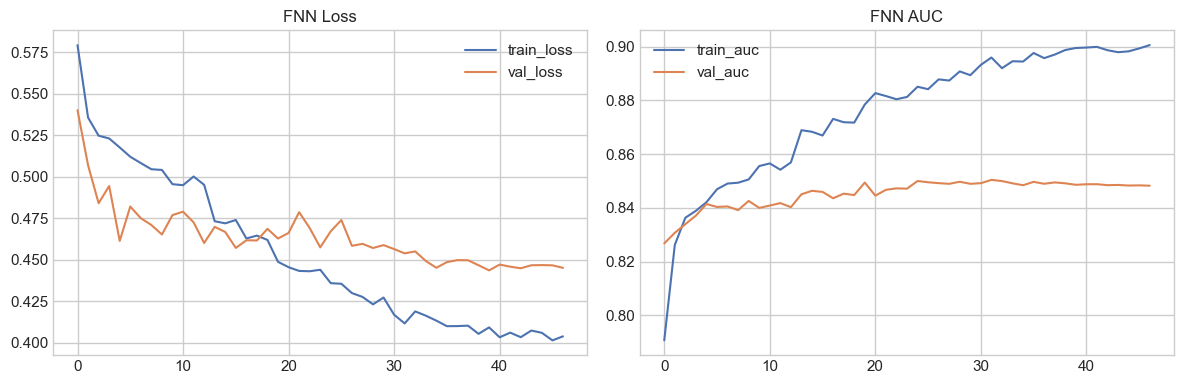

In [9]:
if not TF_AVAILABLE:
    print('TensorFlow nicht verfuegbar in dieser Umgebung - FNN wird uebersprungen.')
    print(globals().get('TF_IMPORT_ERROR'))
else:
    print('\n--- TensorFlow / Keras: Setup ---')
    print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
    print(f'Features pro Sample: {X_train.shape[1]}')
    print(f'Konfiguration: epochs={NN_EPOCHS}, batch_size={NN_BATCH_SIZE}, random_state={RANDOM_STATE}')

    scaler_tf = StandardScaler()
    # Fit nur auf Train verhindert Data Leakage in der Skalierung.
    X_train_tf = scaler_tf.fit_transform(X_train)
    X_val_tf = scaler_tf.transform(X_val)
    X_test_tf = scaler_tf.transform(X_test)

    # Raeumt alte Graphen auf, falls die Zelle mehrfach ausgefuehrt wird.
    tf.keras.backend.clear_session()

    # Fuer stabileres und reproduzierbares Verhalten als float32-Matrizen trainieren.
    X_train_tf = X_train_tf.astype(np.float32)
    X_val_tf = X_val_tf.astype(np.float32)
    X_test_tf = X_test_tf.astype(np.float32)
    y_train_tf = y_train_cls.to_numpy().astype(np.float32)
    y_val_tf = y_val_cls.to_numpy().astype(np.float32)

    # Klassenungleichgewicht abfedern, damit Recall/Precision fuer Hits nicht kippen.
    class_counts = np.bincount(y_train_cls.to_numpy(), minlength=2)
    n_total = class_counts.sum()
    class_weight = {
        0: n_total / (2 * max(class_counts[0], 1)),
        1: n_total / (2 * max(class_counts[1], 1)),
    }
    print('Class counts (Train):', {0: int(class_counts[0]), 1: int(class_counts[1])})
    print('Class weights:', {k: round(v, 4) for k, v in class_weight.items()})

    class EpochLogger(tf.keras.callbacks.Callback):
        # Kompakter Lernfortschritt pro Epoche fuer Nachvollziehbarkeit.
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            loss = logs.get('loss', float('nan'))
            val_loss = logs.get('val_loss', float('nan'))
            acc = logs.get('accuracy', float('nan'))
            val_acc = logs.get('val_accuracy', float('nan'))
            auc = logs.get('auc', float('nan'))
            val_auc = logs.get('val_auc', float('nan'))
            print(
                f"[Epoch {epoch + 1:03d}] "
                f"loss={loss:.4f} val_loss={val_loss:.4f} "
                f"acc={acc:.4f} val_acc={val_acc:.4f} "
                f"auc={auc:.4f} val_auc={val_auc:.4f}"
            )

    fnn = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
        tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    fnn.summary()

    fnn.compile(
        # Binary Crossentropy passt zu binaerer Hit-Klassifikation.
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )

    callbacks = [
        EpochLogger(),
        tf.keras.callbacks.EarlyStopping(
            # Stoppt frueh bei ausbleibender AUC-Verbesserung auf Validation.
            monitor='val_auc',
            mode='max',
            patience=15,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    start = time.perf_counter()
    history = fnn.fit(
        X_train_tf,
        y_train_tf,
        # Validation wird pro Epoche geloggt fuer Early Stopping.
        validation_data=(X_val_tf, y_val_tf),
        epochs=NN_EPOCHS,
        batch_size=NN_BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
        class_weight=class_weight,
    )
    train_seconds = time.perf_counter() - start

    y_prob_fnn = fnn.predict(X_test_tf, verbose=0).ravel()
    # Standard-Entscheidungsgrenze 0.5 fuer Klassenlabels.
    y_pred_fnn = (y_prob_fnn >= 0.5).astype(int)

    fnn_metrics = {
        'accuracy': accuracy_score(y_test_cls, y_pred_fnn),
        'precision': precision_score(y_test_cls, y_pred_fnn, zero_division=0),
        'recall': recall_score(y_test_cls, y_pred_fnn, zero_division=0),
        'f1': f1_score(y_test_cls, y_pred_fnn, zero_division=0),
        'roc_auc': roc_auc_score(y_test_cls, y_prob_fnn),
    }
    print('TensorFlow FNN - Testmetriken:')
    print(pd.Series(fnn_metrics).round(4))
    print(f'Epochen trainiert: {len(history.history["loss"])} / {NN_EPOCHS}')
    print(f'Trainingsdauer: {train_seconds:.1f} Sekunden')
    print('Test-Predictions >= 0.5 (Hits):', int((y_prob_fnn >= 0.5).sum()), 'von', len(y_prob_fnn))
    print('Wahrscheinlichkeitsbereich [min, max]:', f"[{y_prob_fnn.min():.4f}, {y_prob_fnn.max():.4f}]")

    best_epoch = int(np.argmax(history.history['val_auc']))
    print(
        'Beste Val-AUC:',
        f"{history.history['val_auc'][best_epoch]:.4f}",
        'in Epoche',
        best_epoch + 1,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].set_title('FNN Loss')
    axes[0].legend()

    axes[1].plot(history.history['auc'], label='train_auc')
    axes[1].plot(history.history['val_auc'], label='val_auc')
    axes[1].set_title('FNN AUC')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 7) Interpretierbarkeit: Permutation Importance (bestes Klassifikationsmodell)

,feature,importance_mean,importance_std
3,instrumentalness,0.1134,0.0134
7,loudness,0.0996,0.0114
1,danceability,0.0494,0.0052
12,duration,0.0392,0.0078
2,energy,0.0360,0.0069
0,acousticness,0.0357,0.0059
6,valence,0.0108,0.0063
5,speechiness,0.0107,0.0033
4,liveness,0.0043,0.0041
11,time_signature,0.0021,0.0015


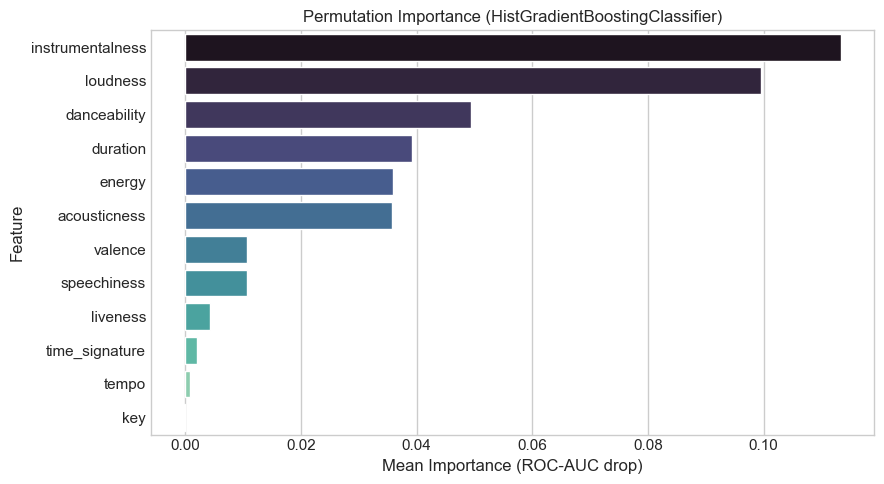

In [10]:
importance = permutation_importance(
    # Misst Performance-Verlust, wenn ein Feature zufaellig durchmischt wird.
    estimator=best_cls_model,
    X=X_test,
    y=y_test_cls,
    scoring='roc_auc',
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

df_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': importance.importances_mean,
    'importance_std': importance.importances_std,
}).sort_values('importance_mean', ascending=False)

display(df_imp.head(12).round(5))

plt.figure(figsize=(9, 5))
sns.barplot(data=df_imp.head(12), x='importance_mean', y='feature', palette='mako')
plt.title(f'Permutation Importance ({best_cls_name})')
plt.xlabel('Mean Importance (ROC-AUC drop)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8) Kurzfazit
- Das Notebook liefert eine **Leakage-bewusste** Hit-Prognose nur mit Audio-Features.
- Du kannst das beste klassische Modell und das TensorFlow-FNN direkt vergleichen.
- Nächster sinnvoller Schritt: Kalibrierung der Entscheidungsschwelle und Business-Simulation (z. B. Top-N Push in Playlists).

In [11]:
con.close()